<a href="https://colab.research.google.com/github/loperasergio94-collab/co2-emissions-renewable-energy-analysis/blob/main/Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📱 Análisis de clientes de ConnectaTel

## Introducción

ConnectaTel es una empresa de telecomunicaciones con operaciones en México y Colombia. En este proyecto analizo cómo usan realmente sus clientes los servicios móviles (llamadas y mensajes), con el objetivo de encontrar patrones de uso, detectar comportamientos atípicos e identificar grupos de clientes con necesidades diferentes.

La idea es que estos hallazgos ayuden a la empresa a mejorar su oferta de planes y la experiencia de sus usuarios.

## 📂 Datos utilizados

Trabajé con tres datasets con información registrada hasta 2024:

- **`plans.csv`**: los planes que ofrece la empresa (precio, minutos y GB incluidos, costo por extra).
- **`users_latam.csv`**: información de 4000 clientes (edad, ciudad, fecha de registro, plan y churn).
- **`usage.csv`**: 40000 registros de uso real, entre llamadas (con su duración) y mensajes (con su longitud).

## ❓ Preguntas que quiero responder

- ¿Qué segmentos de clientes usan más o menos llamadas y mensajes?
- ¿Hay usuarios con valores atípicos que indiquen comportamientos inusuales o errores de registro?
- ¿Cómo cambia el uso según la edad y el plan contratado?
- ¿Qué patrones pueden ayudar a diseñar mejores planes?

## 🔄 Cómo lo abordé

1. **Exploración:** revisar la estructura de cada dataset.
2. **Calidad de datos:** identificar nulos, sentinels y fechas fuera de rango.
3. **Limpieza:** corregir los problemas encontrados.
4. **Estadísticas descriptivas:** entender el comportamiento típico de los clientes.
5. **Visualización y outliers:** ver la forma de los datos y detectar valores extremos.
6. **Segmentación:** agrupar a los clientes por edad y nivel de uso.
7. **Conclusiones:** traducir los hallazgos en recomendaciones para el negocio.

## 🛠️ Herramientas

Python (pandas, numpy, seaborn, matplotlib) en Jupyter Notebook.

---
##  1. Cargar y explorar




### 1.1 Carga de datos y vista rápida


In [ ]:
# importar librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo de los gráficos

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [ ]:
# cargar archivos

plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = usage = pd.read_csv('/datasets/usage.csv')

print("Datasets cargados exitosamente")

Datasets cargados exitosamente


In [ ]:
# mostrar las primeras 5 filas de plans

display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users

display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage

display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN



### 1.2 Exploración de la estructura de los datasets


In [ ]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()

print("Información de Plans")
plans.info()

Información de Plans
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()

print("Información de Users")
users.info()

Información de Users
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()

print("Información de Usage")
usage.info()

Información de Usage
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---


## 2. Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos




In [ ]:
# cantidad de nulos para users

print("Cantidad de valores nulos:")
print(users.isna().sum())

print("Proporción de valores nulos:")
print(users.isna().mean())

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage

print("Cantidad de valores nulos:")
print(usage.isna().sum())

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



**Diagnóstico**

- users['city'] (11.7%): Presenta una cantidad moderada de nulos. Acción: Imputar. Recomiendo llenar los huecos con la etiqueta "Desconocido" para no perder la información de los otros campos del usuario.
- users['churn_date'] (88.3%): Aunque el porcentaje es muy alto, es un nulo informativo. Acción: Ignorar. Representa a los clientes activos que aún no han dejado la empresa.
- usage['date'] (0.12%): Porcentaje insignificante de nulos. Acción: Eliminar filas. Al ser menos del 1% de los datos, eliminarlos no sesga el análisis y asegura que todas las actividades tengan una fecha válida.
- usage['duration'] y ['length'] (~50%): Nulos estructurales. Acción: Ignorar. Son complementarios: si hay duración, no hay longitud (llamadas) y viceversa (mensajes).



In [ ]:
# explorar columnas numéricas de users

users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


**Diagnóstico**

- `user_id`: va de 10000 a 13999 y hay 4000 registros, no hay regidtros ausentes.
- `age`: el mínimo es -999, y nadie tiene -999 años. Es un sentinel, este valor afecta significativamente la std y el promedio.

In [ ]:
# explorar columnas numéricas de usage

usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


**Diagnóstico**

- `id` y `user_id` son identificadores. id va de 1 a 40000 y user_id va de 10000 a 13999, igual que en la tabla users. No presentan valores inválidos.
- Las columnas `duration` y `length` no tienen sentinels evidentes.


In [ ]:

# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

print(users['city'].value_counts(dropna=False))
print(users['plan'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64
Basico     2595
Premium    1405
Name: plan, dtype: int64


**Diagnóstico**

- La columna `city` tiene un sentinel: el valor "?" aparece 96 veces y no es una ciudad válida. Además hay 469 nulos (NaN).
- La columna `plan` está limpia: solo tiene dos valores válidos, Basico (2595) y Premium (1405), sin nulos ni valores raros.

In [ ]:

# explorar columna categórica de usage

usage['type'].value_counts(dropna=False)


text    22092
call    17908
Name: type, dtype: int64

**Diagnóstico de los valores inválidos o sentinels**

- `users['age']`: el valor -999 es un sentinel. Eleva la std y baja el promedio.
**Acción:** reemplazar -999 por nulo (NaN) para que no afecte los cálculos.
- `users['city']`: el valor "?" aparece 96 veces y no es una ciudad válida.       **Acción:** reemplazar "?" por nulo (NaN) y tratarlo igual que los demás faltantes de esta columna ("Desconocido").





### 2.2 Revisión y estandarización de fechas



In [ ]:
# Convertir a fecha la columna `reg_date` de users

users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [ ]:
# Convertir a fecha la columna `date` de usage

usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users

users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

**Diagnóstico**

- En `reg_date`, hay 40 registros con año 2026, lo cual es imposible porque los datos llegan hasta 2024.

In [ ]:
# Revisar los años presentes en `date` de usage

usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

**Diagnóstico**

- En `date`, todas las fechas válidas son del año 2024 (39950 registros), lo cual es coherente con el periodo de análisis. Los 50 registros restantes son los nulos ya identificados.
- `users['reg_date']`: sí aparece un año imposible (2026). Hay 40 registros con año 2026, un año que no había transcurrido al momento de guardar los datos (que llegan hasta 2024). **Acción:** reemplazar esas 40 fechas por nulo (NaT).
- `usage['date']`: Todas las fechas válidas son del 2024.

---

## 3 Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles


In [ ]:
# Reemplazar -999 por la mediana de age

age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios

users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios

users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date

users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios

users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles


In [ ]:
# Verificación MAR en usage (Missing At Random) para duration

usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length

usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

**Diagnóstico de nulos en `duration` y `length`**

- `duration`: el 0% de las llamadas (`call`) tiene nulos, mientras que el 99.9% de los mensajes (`text`) no tiene duración. Los nulos dependen del tipo de evento, porque un mensaje no tiene minutos. Son MAR.
- `length`: el 99.9% de las llamadas no tiene longitud, mientras que casi el 0% de los mensajes tiene nulos. Los nulos dependen del tipo de evento, porque una llamada no tiene caracteres. Son MAR.

---

##  4. Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso


In [ ]:
# Columnas auxiliares

usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({"is_text": "sum", "is_call": "sum", "duration": "sum"}).reset_index()

# observar resultado

usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas

usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado

usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024


In [ ]:
# Resumen estadístico de las columnas numéricas

user_profile[["age", "cant_mensajes", "cant_llamadas", "cant_minutos_llamada"]].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan

user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


---

## 5. Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones



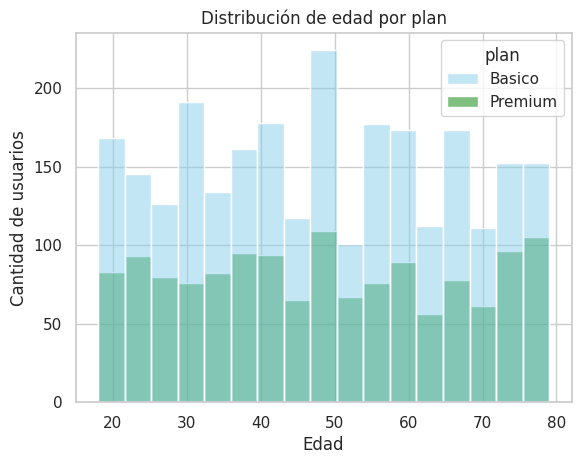

In [ ]:
# Histograma para visualizar la edad (age)

sns.histplot(data=user_profile, x="age", hue="plan", palette=["skyblue", "green"])
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡**Insights:**
- Distribución simétrica y muy uniforme: los usuarios se reparten de forma pareja entre los 18 y los 79 años, sin concentrarse en un grupo de edad.
- En todas las edades hay más usuarios que prefieren el plan Basico que Premium, lo cual coincide con su mayor proporción (65% vs 35%). No existe un patrón claro de edad asociado al plan.
- El pico alrededor de los 47-50 años es debido a los valores sentinel (-999) que se reemplazaron por la mediana (47).

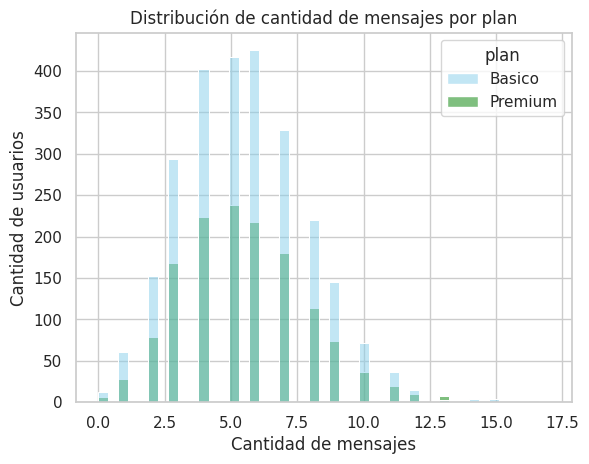

In [ ]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x="cant_mensajes", hue="plan", palette=["skyblue", "green"])
plt.title("Distribución de cantidad de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡**Insights:**
- Distribución levemente sesgada a la derecha: la mayoría de los usuarios envía entre 4 y 7 mensajes, con pocos casos que llegan hasta 15-17.
- Los usuarios Basico y Premium tienen una distribución muy similar, con el pico alrededor de 5 mensajes. La diferencia de altura se debe solo a que hay más usuarios Basico. No existe un patrón de mayor uso de mensajes asociado al plan.

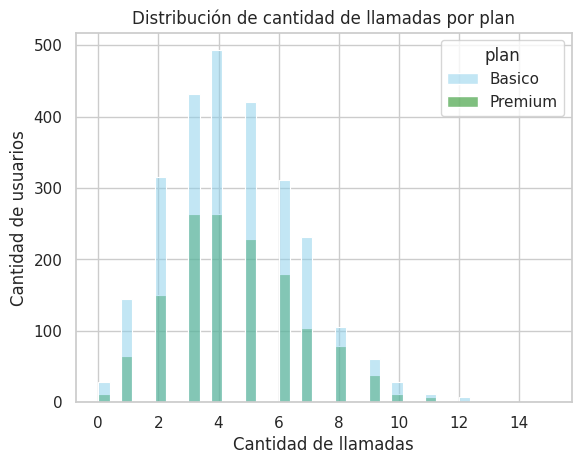

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x="cant_llamadas", hue="plan", palette=["skyblue", "green"])
plt.title("Distribución de cantidad de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()


💡**Insights:**
- Distribución ligeramente sesgada a la derecha: la mayoría de los usuarios realiza entre 3 y 5 llamadas, con el pico en 4 y pocos casos que llegan hasta 12-15.
- Los usuarios Basico y Premium muestran una distribución muy similar. La diferencia de altura se debe a que hay más usuarios Basico.

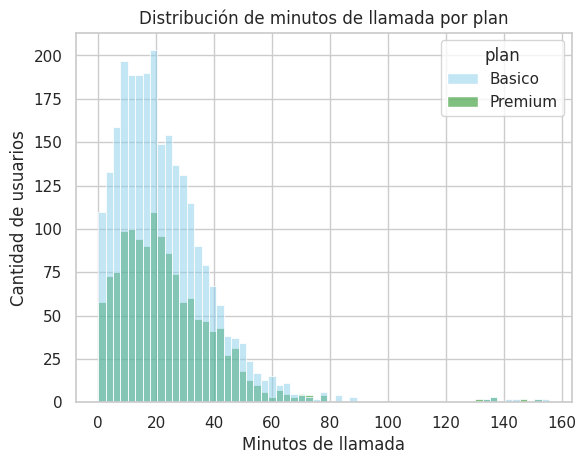

In [ ]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x="cant_minutos_llamada", hue="plan", palette=["skyblue", "green"])
plt.title("Distribución de minutos de llamada por plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡**Insights:**
- Distribución sesgada a la derecha: la mayoría de los usuarios habla entre 5 y 40 minutos, con el pico alrededor de 10-20 minutos, y una cola larga hacia valores altos.
- Hay un pequeño grupo de usuarios entre 130 y 155 minutos, muy separados del resto.
- Los usuarios Basico y Premium tienen una distribución muy similar. No existe un patrón de mayor consumo de minutos asociado al plan.


### 5.2 Identificación de Outliers



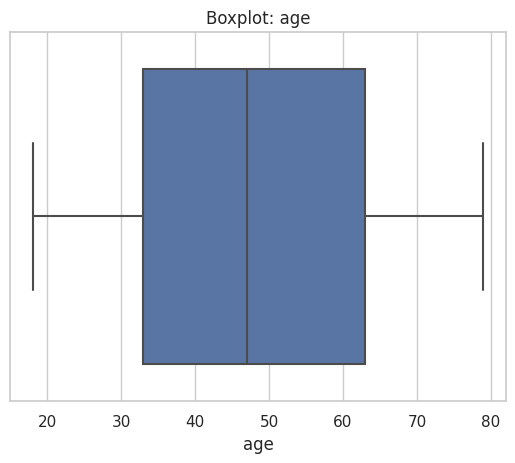

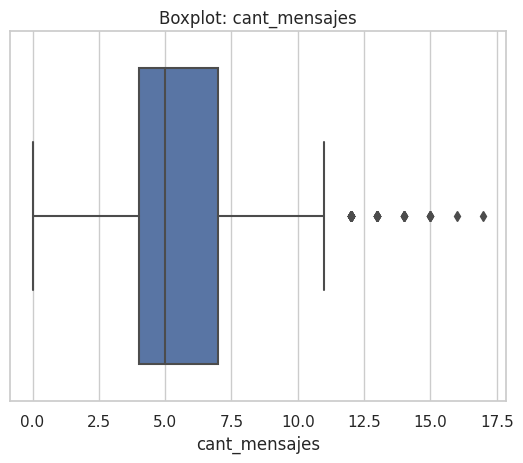

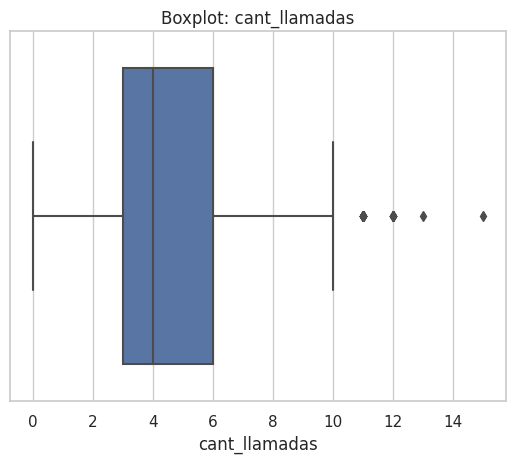

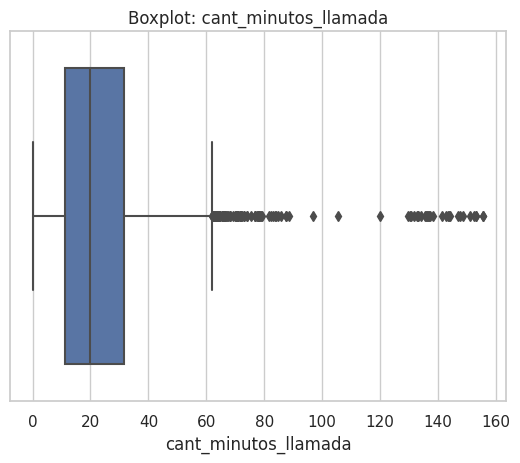

In [ ]:
# Visualizando usando BoxPlot

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()


💡**Insights:**
- `age`: no presenta outliers. Todos los valores están dentro del rango normal (18 a 79 años).
- `cant_mensajes`: presenta outliers solo en el lado superior: usuarios con 12 a 17 mensajes, por encima del bigote superior (~11).
- `cant_llamadas`: presenta outliers solo en el lado superior: usuarios con 11 a 15 llamadas, por encima del bigote superior (~10).
- `cant_minutos_llamada`: presenta outliers solo en el lado superior, en mayor cantidad: usuarios desde ~62 hasta 155 minutos, con un grupo aislado entre 130 y 155 minutos.

In [ ]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite superior = {limite_superior}")


cant_mensajes: límite superior = 11.5
cant_llamadas: límite superior = 10.5
cant_minutos_llamada: límite superior = 61.8575


In [ ]:


# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()



,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡**Insights:**
- Los valores máximos superan los límites IQR (17 vs 11.5 en mensajes, 15 vs 10.5 en llamadas y 155.7 vs 61.9 en minutos), pero todos son valores posibles y no errores de captura.
- Decisión: mantener los outliers, ya que representan a usuarios con alto consumo, relevantes para la segmentación y para identificar candidatos a planes de mayor capacidad.

---

##  6. Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso


In [ ]:
# Crear columna grupo_uso

user_profile['grupo_uso'] = 'Alto uso'

user_profile.loc[(user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10), 'grupo_uso'] = 'Uso medio'

user_profile.loc[(user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5), 'grupo_uso'] = 'Bajo uso'

In [ ]:
# verificar cambios

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [ ]:
# Verificar cuántos usuarios hay en cada grupo de uso

user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

### 6.2 Segmentación de Clientes Por Edad



In [ ]:
# Crear columna grupo_edad

user_profile['grupo_edad'] = 'Adulto Mayor'

user_profile.loc[user_profile['age'] < 60, 'grupo_edad'] = 'Adulto'

user_profile.loc[user_profile['age'] < 30, 'grupo_edad'] = 'Joven'

In [ ]:
# verificar cambios

user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [ ]:
# Verificar cuántos usuarios hay en cada grupo de edad

user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

### 6.3 Visualización de la Segmentación de Clientes


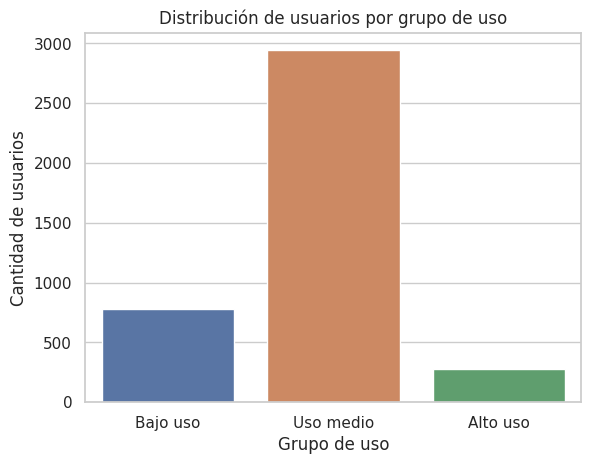

In [ ]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso', order=['Bajo uso', 'Uso medio', 'Alto uso'])
plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

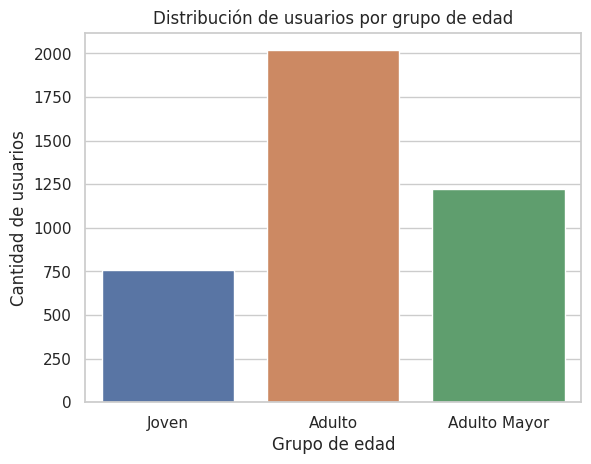

In [ ]:
# Visualización de los segmentos por edad

sns.countplot(data=user_profile, x='grupo_edad', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

💡**Insights:**
- Por uso: la gran mayoría de los usuarios (73.6%) tiene uso medio. Solo el 7% tiene alto uso, un grupo pequeño pero valioso para ofrecer planes de mayor capacidad.
- Por edad: predominan los Adultos (50.5%), seguidos por los Adultos Mayores (30.6%) y los Jóvenes (19%). La base de clientes tiene más Adultos Mayores que Jóvenes, lo cual es relevante para diseñar planes y estrategias de retención.


---
## 7. Insight Ejecutivo para Stakeholders




### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En `users` encontré 565 usuarios sin ciudad (14.1%): 469 nulos y 96 con "?", edades de -999 que reemplacé por la mediana (47) y 40 fechas de registro en 2026 (1%), que dejé como nulas porque los datos llegan hasta 2024.
- En `usage` había 50 registros sin fecha (0.12%). Los nulos de `duration` y `length` (~50%) los dejé así, porque los mensajes no tienen duración y las llamadas no tienen longitud.

🔍 **Segmentos por Edad**
- La mitad de los clientes son adultos de 30 a 59 años (50.5%), seguidos por adultos mayores (30.6%) y jóvenes (19%). Me sorprendió que haya más adultos mayores que jóvenes.
- No vi relación entre la edad y el plan: hay usuarios Basico y Premium en todas las edades.

📊 **Segmentos por Nivel de Uso**
- La mayoría tiene uso medio (73.6%), el 19.5% uso bajo y solo el 7% uso alto. Encontré outliers, sobre todo en minutos (un grupo habla entre 130 y 155), pero los mantuve porque son clientes reales que usan mucho el servicio.
- Lo que más me llamó la atención: los usuarios Premium y Basico usan el servicio casi igual.

➡️ Esto sugiere que muchos clientes no tienen el plan que corresponde a su consumo: algunos Premium pagan de más sin aprovecharlo, y algunos Basico con uso alto necesitarían un plan mejor.

💡 **Recomendaciones**
- Ofrecer Premium a los usuarios Basico de alto uso y revisar qué beneficios da el Premium, para que sus usuarios sientan la diferencia y no cancelen.
- Crear un plan intermedio para el grupo de uso medio (la mayoría) y, como siguiente paso, analizar el churn por segmento para ver qué grupos tienen más riesgo de irse.